# BasisVAE demo

This notebook loads a synthetic data cube and a fixed source mask from
`../data/tutorial_demo.fits`, generated by `tutorial_demo_frame.ipynb`, and fits
the `comicsnet.BasisVAE` background model.

The data cube contains a time-variable background and a moving compact
source. Each optimization step uses one complete detector frame. The
model reconstructs each frame as a linear combination of detector-fixed
basis images while excluding masked pixels from the reconstruction loss.


In [33]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import jax
import astropy.io.fits as fits

from comicsnet import Config, BasisVAE, fit

jax.config.update('jax_enable_x64', True)

rcParams['image.origin'] = 'lower'
rcParams['legend.frameon'] = False

## Demo data

Load the data cube from the primary HDU and the source mask from the
`MASK` extension. Both have shape `(time, y, x)`. Mask values of 1 mark
pixels excluded from background fitting; values of 0 mark observed pixels.


In [34]:
cube = fits.open('../data/tutorial_demo.fits')[0].data
mask = fits.open('../data/tutorial_demo.fits')['MASK'].data
nz, ny, nx = cube.shape

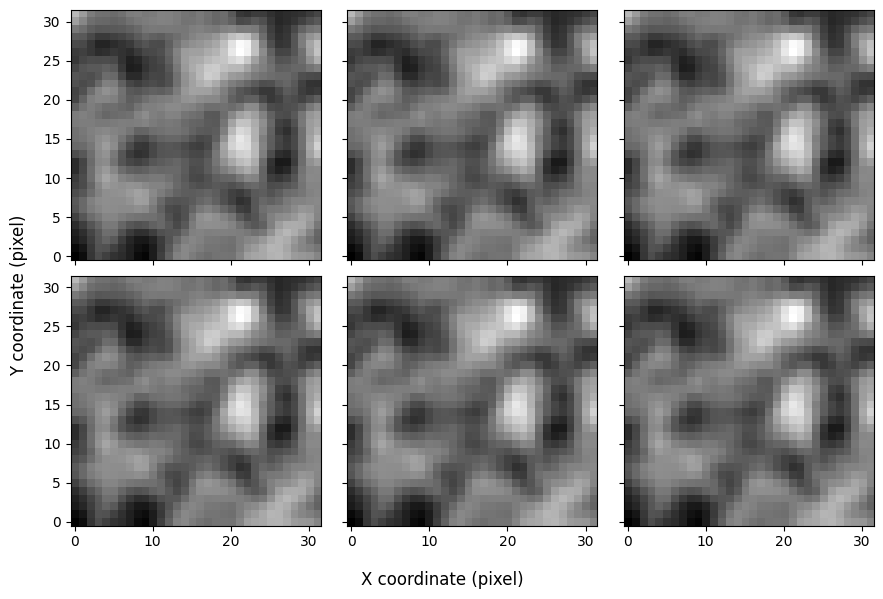

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharex=True, sharey=True)

for n, ax in enumerate(axes.flatten()):
  ax.imshow(cube[n], cmap='gray')

fig.supxlabel('X coordinate (pixel)', fontsize=12)
fig.supylabel('Y coordinate (pixel)', fontsize=12)

fig.tight_layout()
plt.show()

## Fit BasisVAE with a fixed mask

The model learns detector-fixed basis images and frame-wise coefficients.
Pass the source mask using `fit(model, cube, mask=mask, config=config)`.
With `update_mask=False`, this mask stays fixed throughout training and
final prediction, and is returned as `result.mask` after conversion to bool.

Internally, observation weights are `1 - mask`. The encoder concatenates
the weighted image and the weights, flattens them, and uses a nonlinear
network to predict the mean and log variance of a Gaussian latent vector.
During training, the decoder maps a sampled latent vector to basis
coefficients and reconstructs the full frame, including masked pixels.

Adjust `hidden_dim` and `latent_dim` for the encoder capacity, and
`basis_dim` for the number of basis images. `inner_steps` and `outer_steps`
control the number of optimization steps.

No frame number or time coordinate is supplied. For final prediction,
`predict(x, weight)` decodes the latent mean instead of drawing a sample.


In [36]:
config = Config(
  outer_steps=1,
  inner_steps=500000,
  learning_rate=lambda n: 5e-4 * 0.5 ** (n / 1e5),
  beta=1.0e-4,
  update_mask=False,
  seed=1,
)

model_key = jax.random.PRNGKey(2)
model = BasisVAE(
  frame_shape=(ny, nx),
  basis_dim=1,
  hidden_dim=8,
  latent_dim=4,
  key=model_key,
)

result = fit(model, cube, mask=mask, config=config)

The plot shows the last 20,000 optimization steps. Each step uses one
randomly selected frame. The loss combines the Gaussian negative log
likelihood averaged over unmasked pixels in standardized data with a KL
term toward a standard normal latent prior, averaged over latent dimensions.
`beta` controls the KL term weight. The fixed mask applies to the
reconstruction term, not the KL term; the loss is not evaluated over the
full data cube.


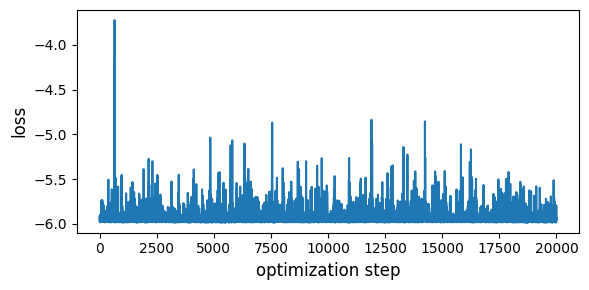

In [37]:
fig, ax = plt.subplots(figsize=(6, 3))

ax.plot(result.losses[-20000:])

ax.set_xlabel('optimization step', fontsize=12)
ax.set_ylabel('loss', fontsize=12)

fig.tight_layout()
plt.show()

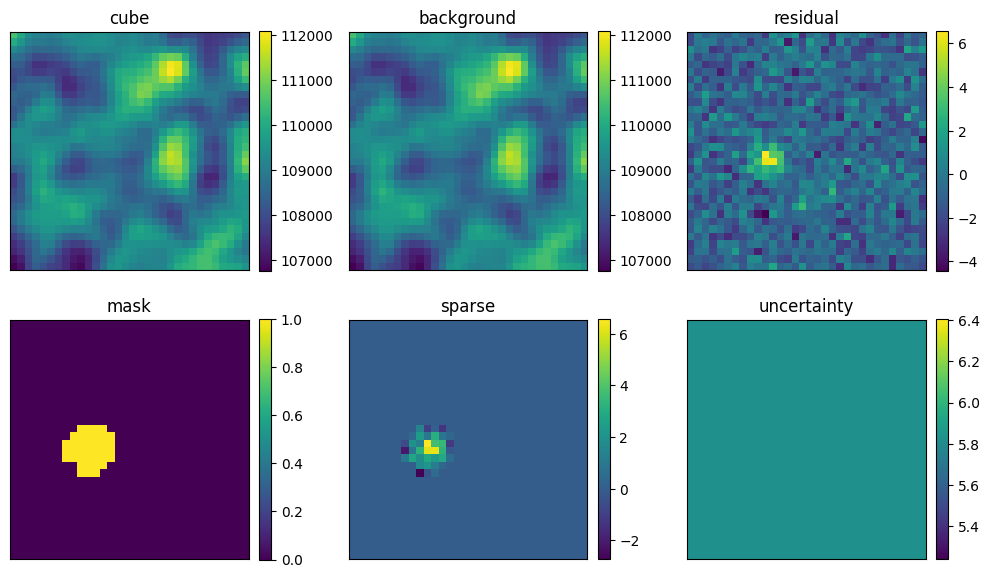

In [38]:
frame_index = 40

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
items = [
  ('cube', cube[frame_index]),
  ('background', result.background[frame_index]),
  ('residual', result.residual[frame_index]),
  ('mask', result.mask[frame_index]),
  ('sparse', result.sparse[frame_index]),
  ('uncertainty', result.uncertainty[frame_index]),
]

for axis, (title, image) in zip(axes.ravel(), items):
  handle = axis.imshow(image, origin='lower', cmap='viridis')
  axis.set_title(title)
  axis.set_xticks([])
  axis.set_yticks([])
  fig.colorbar(handle, ax=axis, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

In [39]:
hdul = fits.HDUList([
  fits.PrimaryHDU(data=result.residual),
  fits.ImageHDU(data=result.background, name='MODEL'),
  fits.ImageHDU(data=result.mask.astype('int16'), name='MASK'),
  fits.ImageHDU(data=result.uncertainty, name='ERROR'),
])
hdul.writeto('../data/tutorial_BasisVAE.fits', overwrite=True)

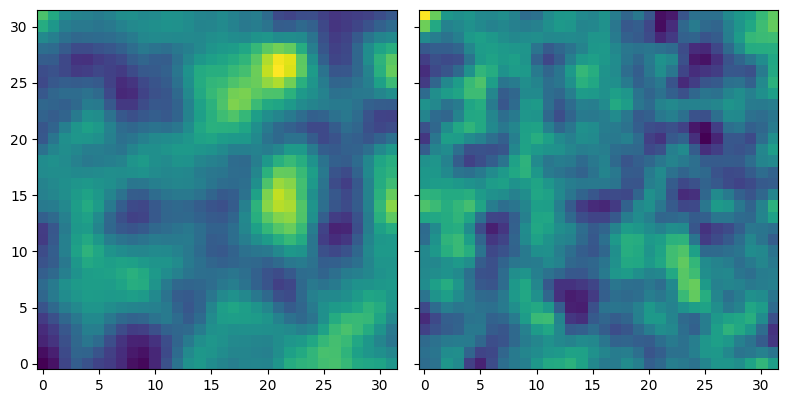

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

axes[0].imshow(result.model.bias)
axes[1].imshow(result.model.basis[0])

fig.tight_layout()
plt.show()